In [2]:
import pandas as pd
import numpy as np

In [3]:
#loading data
credit_df = pd.read_csv('kenyan_fintech_raw_data.csv')

## Data quality audit

In [4]:
#check duplicates
credit_df.duplicated().sum()

np.int64(99)

There are 99 duplicates in our data

In [5]:
#handling duplicates
credit_df.drop_duplicates()

,Customer_ID,Age,Gender,Location,Avg_Monthly_MPesa_Inflow,Airtime_Spend,Years_in_Business,Utility_Bill_Score,Loan_Amount_Requested,Default_Status
0,CUST-1000,56,Male,Nairobi,38300.602500,770.290833,1,0.922156,5000,0
1,CUST-1001,69,Male,NRB,37712.789140,1556.559207,7,0.054201,25000,0
2,CUST-1002,46,Male,Eldoret,26134.389930,756.912944,19,0.688913,50000,0
3,CUST-1003,32,NaN,Kisumu,40913.425888,1010.394375,8,0.621240,25000,0
4,CUST-1004,60,Male,Kisumu,32320.292035,1964.860617,3,0.441042,10000,0
...,...,...,...,...,...,...,...,...,...,...
4996,CUST-5996,39,Female,Mombasa,43482.232545,1400.828226,9,0.699656,50000,0
4997,CUST-5997,46,Male,Mombasa,NaN,2197.460963,7,0.029634,10000,0
4998,CUST-5998,39,Female,Kisumu,58748.579121,1275.961909,8,0.690630,10000,0
4999,CUST-5999,61,Male,nairobi,NaN,664.317434,2,0.457178,25000,1


In [6]:
#check missing values
credit_df.isnull().sum()

Customer_ID                   0
Age                           0
Gender                      503
Location                      0
Avg_Monthly_MPesa_Inflow    410
Airtime_Spend               407
Years_in_Business             0
Utility_Bill_Score          411
Loan_Amount_Requested         0
Default_Status                0
dtype: int64

In [7]:
#standardization of categorical data
credit_df['Gender'].value_counts()

Gender
Male      2077
Female    2014
F          268
M          238
Name: count, dtype: int64

In [8]:
credit_df['Gender'] = credit_df['Gender'].replace({ 'F' : 'Female', 'M' : 'Male'})

In [9]:
credit_df['Location'].value_counts()

Location
Eldoret    760
Nakuru     757
NRB        736
Mombasa    728
nairobi    719
Kisumu     702
Nairobi    698
Name: count, dtype: int64

In [10]:
credit_df['Location'] = credit_df['Location']. replace({'nairobi': 'Nairobi', 'NRB': 'Nairobi'})

### Outliers treatment

In [11]:
#checking outliers
credit_df.describe()

,Age,Avg_Monthly_MPesa_Inflow,Airtime_Spend,Years_in_Business,Utility_Bill_Score,Loan_Amount_Requested,Default_Status
count,5100.000000,4.690000e+03,4693.000000,5100.000000,4689.000000,5100.000000,5100.000000
mean,46.271373,4.550714e+04,1182.291685,9.542353,0.493425,20803.921569,0.150588
std,16.637727,2.295415e+05,581.935900,5.718538,0.286581,15797.762878,0.357682
min,18.000000,-2.139668e+04,-719.856337,0.000000,0.000067,5000.000000,0.000000
25%,32.000000,2.449563e+04,791.166468,5.000000,0.244980,10000.000000,0.000000
50%,46.000000,3.509269e+04,1184.151129,10.000000,0.487608,15000.000000,0.000000
75%,61.000000,4.523669e+04,1574.912248,14.000000,0.740914,25000.000000,0.000000
max,150.000000,5.000000e+06,3190.612232,19.000000,0.999732,50000.000000,1.000000


In [12]:
#fixing logical outliers(age and negative values)
credit_df = credit_df [(credit_df ['Age'] < 100) & (credit_df ['Airtime_Spend'] > 0)]


Dropped age values greater than 100 because thats mainly the age limit and also the negative values in the airtime spend column. we can't have negative values of airtime spend because its either the customer spent airtime or did not.

In [13]:
#handling financial outliers in the average monthly mpesa inflow
#using interquantile range method
Q1 = credit_df['Avg_Monthly_MPesa_Inflow'].quantile(0.25)
Q3 = credit_df['Avg_Monthly_MPesa_Inflow'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [14]:
#filtering out extreme outliers
credit_df[(credit_df['Avg_Monthly_MPesa_Inflow'] >= lower_bound) & (credit_df['Avg_Monthly_MPesa_Inflow'] <= upper_bound)]

,Customer_ID,Age,Gender,Location,Avg_Monthly_MPesa_Inflow,Airtime_Spend,Years_in_Business,Utility_Bill_Score,Loan_Amount_Requested,Default_Status
0,CUST-1000,56,Male,Nairobi,38300.602500,770.290833,1,0.922156,5000,0
1,CUST-1001,69,Male,Nairobi,37712.789140,1556.559207,7,0.054201,25000,0
2,CUST-1002,46,Male,Eldoret,26134.389930,756.912944,19,0.688913,50000,0
3,CUST-1003,32,NaN,Kisumu,40913.425888,1010.394375,8,0.621240,25000,0
4,CUST-1004,60,Male,Kisumu,32320.292035,1964.860617,3,0.441042,10000,0
...,...,...,...,...,...,...,...,...,...,...
5094,CUST-4479,69,Male,Kisumu,15880.446712,1425.618398,14,0.066284,5000,0
5095,CUST-5300,66,Male,Nairobi,22070.256551,405.805961,9,0.007128,5000,0
5097,CUST-4811,43,Female,Nakuru,30969.396481,1771.392085,8,NaN,25000,0
5098,CUST-1197,61,Female,Nairobi,50783.839006,1309.415411,16,0.788835,50000,0


### Handling missing values

In [15]:
credit_df.isnull().sum()

Customer_ID                   0
Age                           0
Gender                      446
Location                      0
Avg_Monthly_MPesa_Inflow    374
Airtime_Spend                 0
Years_in_Business             0
Utility_Bill_Score          368
Loan_Amount_Requested         0
Default_Status                0
dtype: int64

In [16]:
#filling average monthly mpesa inflow with median
credit_df['Avg_Monthly_MPesa_Inflow'] = credit_df['Avg_Monthly_MPesa_Inflow'].fillna(credit_df['Avg_Monthly_MPesa_Inflow'].median())

The average monthly mpesa inflow was filled with median because the data distribution was positively skewed, indicating presence of outliers. since mean is sensitive to outliers using it to impute missing values would bias the data. median is more robust and better represents positively skewed data

In [17]:
credit_df ['Utility_Bill_Score'] = credit_df['Utility_Bill_Score'].fillna ('Unknown')

The utility bill score was filled with unknown so that to flag those rows which might indicate or reflect individuals operating in the informal sectors and lacks formal utility records

In [18]:
#filling missing values in gender column with unknown
credit_df['Gender'] = credit_df['Gender'].fillna (' Unknown')

Both male and female shares equal percentages thus filling missing values with mode would not work. the values were imputted using unknown to show lack of gender information

In [19]:
#checking for missing values
credit_df.isnull().sum()

Customer_ID                 0
Age                         0
Gender                      0
Location                    0
Avg_Monthly_MPesa_Inflow    0
Airtime_Spend               0
Years_in_Business           0
Utility_Bill_Score          0
Loan_Amount_Requested       0
Default_Status              0
dtype: int64

In [20]:
#checking if location is clean
credit_df['Location'].value_counts()

Location
Nairobi    1928
Nakuru      683
Eldoret     676
Mombasa     666
Kisumu      629
Name: count, dtype: int64

In [21]:
#gender
credit_df['Gender'].value_counts()

Gender
Male        2068
Female      2068
 Unknown     446
Name: count, dtype: int64

In [22]:
#saving the cleaned data
credit_df.to_csv('cleaned_kenyan_fintech_data.csv')

### Exploratory Data Analysis

In [23]:
!pip install seaborn

In [24]:
!pip install scikit-learn

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
sns.set_theme( style = 'whitegrid')

/tmp/ipykernel_939/1543140630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = credit_df, x = 'Default_Status', palette= 'viridis')


Text(0.5, 1.0, 'Overall Default Distribution  (0 = Paid, 1 = Defaulted)')

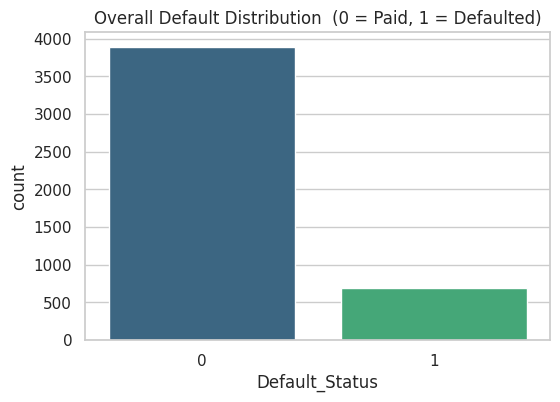

In [27]:
#distribution of defaults
plt.figure(figsize = (6,4))
sns.countplot(data = credit_df, x = 'Default_Status', palette= 'viridis')
plt.title('Overall Default Distribution  (0 = Paid, 1 = Defaulted)')

/tmp/ipykernel_939/3421168170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = credit_df, x = 'Default_Status', y = 'Airtime_Spend',palette= 'Set2')


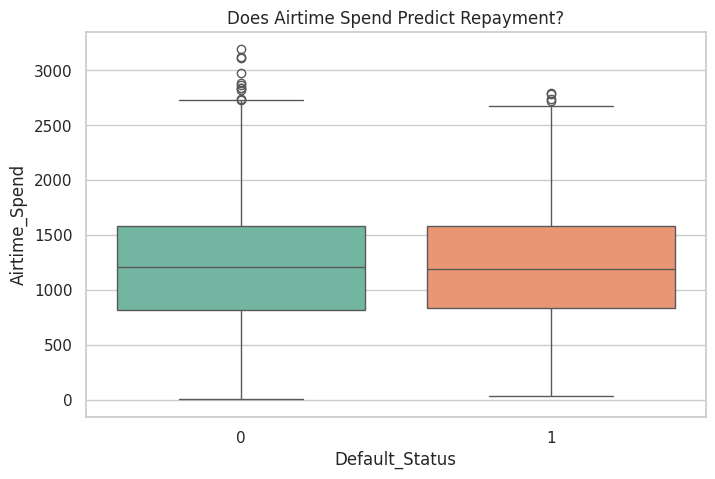

In [30]:
plt.figure(figsize = (8,5))
sns.boxplot(data = credit_df, x = 'Default_Status', y = 'Airtime_Spend',palette= 'Set2')
plt.title('Does Airtime Spend Predict Repayment?')
plt.show()
          

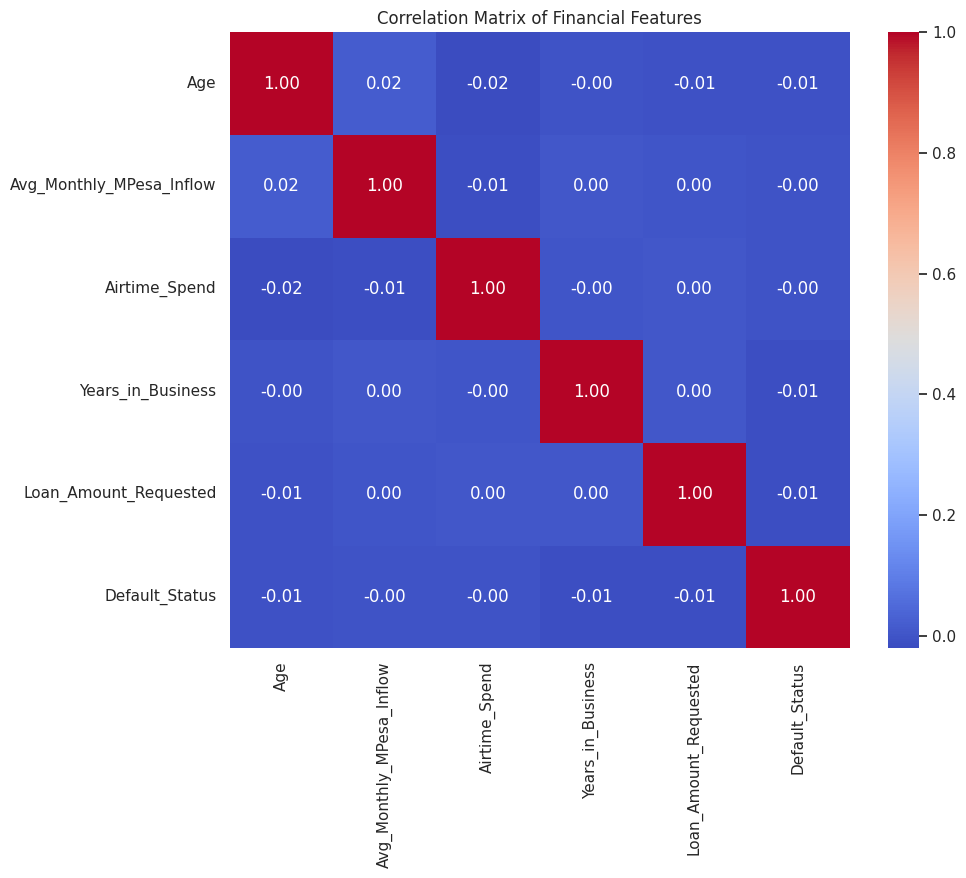

In [31]:
#correlation heatmap
plt.figure(figsize=(10,8))
corr = credit_df.corr(numeric_only= True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix of Financial Features')
plt.show()

CREDIT SCORE MODELLING

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
#preparing features(X) and target variable(y)
X = credit_df.drop(['Default_Status', 'Location', 'Customer_ID'], axis = 1, errors = 'ignore')
y = credit_df['Default_Status']

In [35]:
#encoding categorical values(Gender)
X = pd.get_dummies(X, drop_first=True)

In [36]:
#data splitting
#training (80%) and testing(20%)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [37]:
#model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [38]:
#predicting
y_pred = model.predict(X_test)

In [40]:
#model evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       773
           1       1.00      0.03      0.05       144

    accuracy                           0.85       917
   macro avg       0.92      0.51      0.49       917
weighted avg       0.87      0.85      0.78       917

